## Bibliotecas e GPU

In [1]:
# Bibliotecas
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from funcs import modificacoes1, banco, tvt, modificacoes2
from redes.unet import unet 
from redes.ResUnet import MultiResUnet


import tensorflow as tf
from tensorflow import keras
from keras import mixed_precision
from keras.callbacks import EarlyStopping


I0000 00:00:1774395622.358962   10121 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774395622.979176   10121 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774395626.084418   10121 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Configuração (GPU / mixed precision / strategy)

print('TensorFlow:', tf.__version__)
print('Built with CUDA:', tf.test.is_built_with_cuda())

gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print('GPUs:', gpus)
print('CPUs:', cpus)

# Importante: fazer isso ANTES de criar modelos/estratégias, para evitar reservar toda a VRAM
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception as e:
            print('Não foi possível habilitar memory growth:', e)

    # Mixed precision costuma reduzir MUITO o uso de VRAM em U-Net
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision policy:', mixed_precision.global_policy())

# Estratégia: só use MirroredStrategy se tiver >1 GPU
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()
print('Strategy:', type(strategy).__name__)

TensorFlow: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">
Strategy: _DefaultDistributionStrategy


## Criando o banco de dados

In [3]:
""" Renomeia os arquivos do label_studio """
# path_y_train = 'banco2/Nelore2/label_studio'
# path_x_train = 'banco2/Nelore2/img_corte'
# y_destino = 'banco2/Nelore2/label_egl'
# lista_img_train = sorted(os.listdir(path_x_train))
# lista_img_label = sorted(os.listdir(path_y_train))
# print(lista_img_label)

# for i,nome_arquivo in enumerate(lista_img_label):
#     caminho = os.path.join(path_y_train, nome_arquivo)
#     img = cv2.imread(caminho)

#     nome_limpo, ext = os.path.splitext(lista_img_train[i])
#     novo_nome = f'{nome_limpo}.jpg'
#     destino = os.path.join(y_destino, novo_nome)
#     cv2.imwrite(destino, img)

' Renomeia os arquivos do label_studio '

In [3]:
path_x_train = 'banco2/TreinoGeral/EGL/imgs'
path_y_train = 'banco2/TreinoGeral/EGL/labels'

x_train, nomes_train = banco(path_x_train, resolution=(256,256), grayscale= True, nomes=True)
y_train, labels_train = banco(path_y_train, resolution=(256,256), grayscale= True, nomes=True)

print(f'Tamanho x_train: {x_train.shape}, y_train: {y_train.shape}')

Tamanho x_train: (134, 256, 256, 1), y_train: (134, 256, 256, 1)


In [15]:
""" Visualizando algumas imagens e labels """
def plot_img_mask(img_list, mask_list, num_pairs = 5, label = None):
    n = num_pairs
    plt.figure(figsize=(10, 6))
    for i in range(n):
        idx = random.randint(0, len(img_list) - 1)
        img = img_list[idx]
        mask = mask_list[idx]
        plt.subplot(2, n, i + 1)
        plt.imshow(img, cmap='gray')
        if label is not None and len(label) > idx:
            plt.title(f"Imagem = {label[idx][2:6]}, index =  {idx}", fontsize=9)
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(mask)
        if label is not None and len(label) > idx:
            plt.title(f"Label = {label[idx][2:6]}, index = {idx}", fontsize=9)
        plt.axis("off")
        del img, mask

In [5]:
""" Função tvt: train, val, test """
x_train, y_train, nomes_train, x_val, y_val, nomes_val, x_test, y_test, nomes_test = tvt(x_train, y_train, partition=(0.7, 0.2, 0.1), nomes = labels_train) # 70% treino, 20% validação, 10% teste

In [6]:
# Prints de verificação dos conjuntos
print(f'Imagens X treino: {x_train.shape}')
print(f'Imagens Y treino: {y_train.shape}')
print(f'Nomes treino: {len(nomes_train)}')

print(f'Imagens X teste: {x_test.shape}')
print(f'Imagens Y teste: {y_test.shape}')
print(f'Nomes teste: {len(nomes_test)}')

print(f'Imagens X validação: {x_val.shape}')
print(f'Imagens Y validação: {y_val.shape}')
print(f'Nomes validação: {len(nomes_val)}')

Imagens X treino: (93, 256, 256, 1)
Imagens Y treino: (93, 256, 256, 1)
Nomes treino: 93
Imagens X teste: (15, 256, 256, 1)
Imagens Y teste: (15, 256, 256, 1)
Nomes teste: 15
Imagens X validação: (26, 256, 256, 1)
Imagens Y validação: (26, 256, 256, 1)
Nomes validação: 26


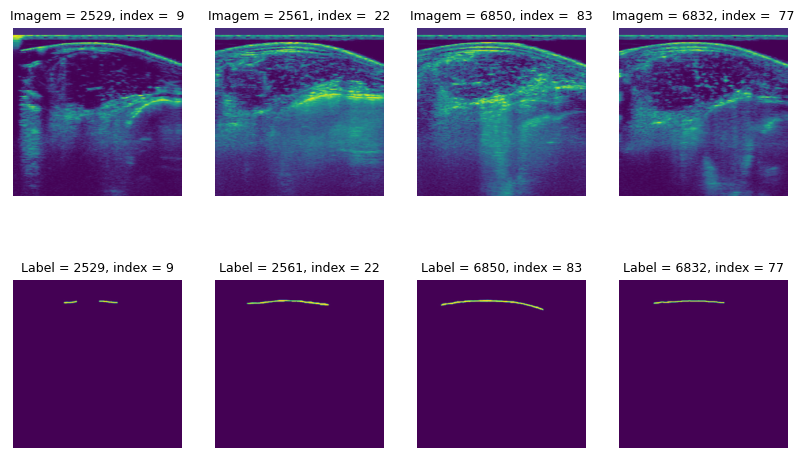

In [7]:
# Plot da função
plot_img_mask(x_train, y_train, num_pairs= 4, label= labels_train)

In [8]:
""" Modifica o banco de dados"""
# x_train
# Função para fazer as modificações nas imagens
dict_x_train, x_train_m = modificacoes1(x_train, 
             nomes_train, 
             original = True, 
             brilho = 1.7,
             escura= 0.5,
             rotacao=[-30,30])

dict_x_val, x_val_m = modificacoes1(x_val,
             nomes_val,
             original = True, 
             brilho = 1.7,
             escura= 0.5,
             rotacao=[-30,30])

print(f'Quantidade de chaves em dict_x_train: {len(dict_x_train.keys())}')
print(f'Quantidade de valores em dict_x_train: {len(dict_x_train.values())}')

Quantidade de chaves em dict_x_train: 372
Quantidade de valores em dict_x_train: 372


In [11]:
# Modificando as labels
y_train_m = dict(zip(nomes_train, y_train))
y_val_m = dict(zip(nomes_val, y_val))
print(f'Quantidade de chaves em y_train: {len(y_train_m)}')   
print(f'Quantidade de chaves em y_val: {len(y_val_m)}')

Quantidade de chaves em y_train: 93
Quantidade de chaves em y_val: 26


In [12]:
# # # y_train
## duplica imagens de label se necessario
y_train_m, y_train_nomes = modificacoes2(y_train_m, dict_x_train.keys())
y_val_m, y_val_nomes = modificacoes2(y_val_m, dict_x_val.keys())

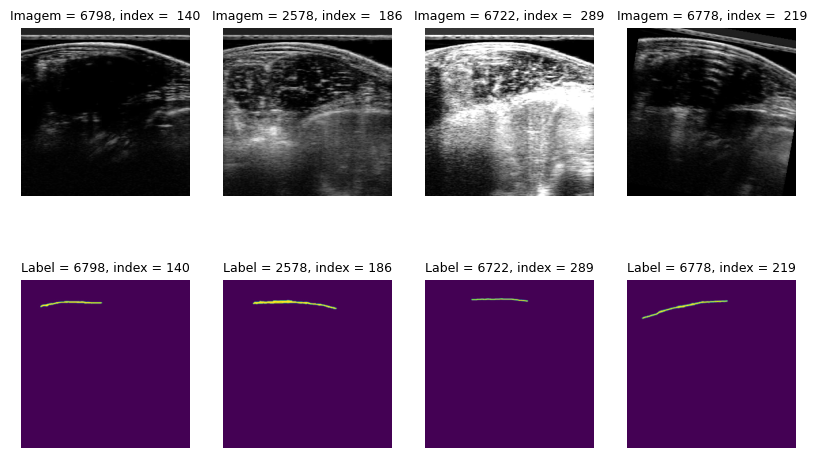

In [38]:
plot_img_mask(x_train_m, y_train_m, num_pairs= 4, label= y_train_nomes)

In [12]:
x_train_m = np.array(x_train_m)
y_train_m = np.array(y_train_m)

x_val_m = np.array(x_val_m)
y_val_m = np.array(y_val_m)

In [13]:
threshold = 0.5
y_train_m = (y_train_m > threshold).astype(np.float32)
y_val_m = (y_val_m > threshold).astype(np.float32)

In [14]:
print(f"Quantidade de imagens em x_train_modificado: {x_train_m.shape}")
print(f"Quantidade de imagens em y_train_modificado: {y_train_m.shape}")

print(f"Quantidade de imagens em x_val_modificado: {x_val_m.shape}")
print(f"Quantidade de imagens em y_val_modificado: {y_val_m.shape}")

Quantidade de imagens em x_train_modificado: (372, 256, 256, 1)
Quantidade de imagens em y_train_modificado: (372, 256, 256, 1)
Quantidade de imagens em x_val_modificado: (104, 256, 256, 1)
Quantidade de imagens em y_val_modificado: (104, 256, 256, 1)


In [15]:
class_train = np.array([0 if nome[2:3] == '6'  else 1 for nome in y_train_nomes], dtype=np.float32)
print(len(class_train))

class_val = np.array([0 if nome[2:3] == '6'  else 1 for nome in y_val_nomes], dtype=np.float32)
print(len(class_val))


372
104


## Dados desbalanceados
- Estou fazendo isso pois na EGL a máscara tem mais pixels pretos do que brancos. 

In [15]:
from sklearn.utils import class_weight

# Vetorize as labels para calcular os class weights
threshold = 0.5
y_train_limiar = (y_train_m > threshold).astype(int)
y_train_flat = y_train_limiar.flatten()
classes = np.unique(y_train_flat)
print("Classes encontradas:", classes)
# Calcule os class weights
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_train_flat)
class_weights_dict = dict(enumerate(class_weights))

w0 = float(class_weights_dict[0])
w1 = float(class_weights_dict[1])

Classes encontradas: [0 1]


In [33]:
import json

with open("class_weights_egl_v3.json", "w") as f:
    json.dump(class_weights_dict, f, indent=2)

## Salvando x_teste para testes futuros

In [16]:
# Pasta base de saída
out_base = "banco2/TreinoGeral/EGL/validacaoGeralV4"
out_x = os.path.join(out_base, "x_test")
out_y = os.path.join(out_base, "y_test")
os.makedirs(out_x, exist_ok=True)
os.makedirs(out_y, exist_ok=True)

def to_uint8(img):
    """Converte imagem para uint8 [0,255], tratando float/bool e canal único."""
    arr = np.squeeze(img)  # remove canal extra (H,W,1) -> (H,W)
    if arr.dtype == np.bool_:
        arr = arr.astype(np.uint8) * 255
    elif np.issubdtype(arr.dtype, np.floating):
        # Se estiver normalizada em [0,1], escala para [0,255]
        arr = np.clip(arr, 0, 1)
        arr = (arr * 255).astype(np.uint8)
    else:
        arr = arr.astype(np.uint8)
    return arr

for i in range(len(x_test)):
    nome_base = nomes_test[i] if "nomes_test" in globals() and i < len(nomes_test) else f"img_{i:04d}"
    nome_base = os.path.splitext(os.path.basename(str(nome_base)))[0]

    img_x = to_uint8(x_test[i])
    img_y = to_uint8(y_test[i])

    cv2.imwrite(os.path.join(out_x, f"{nome_base}.jpg"), img_x)
    cv2.imwrite(os.path.join(out_y, f"{nome_base}.jpg"), img_y)

print(f"Salvo em: {os.path.abspath(out_base)}")
print(f"Total de pares salvos: {len(x_test)}")

Salvo em: /home/victors/Documents/Codigos_Mestrado/banco2/TreinoGeral/EGL/validacaoGeralV4
Total de pares salvos: 15


## Métricas & Funções

In [17]:
# Definindo uma função de perda baseada nos class weights
def weighted_binary_crossentropy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Binary crossentropy padrão
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    # Aplica os pesos às classes
    weights = y_true * w1 + (1.0 - y_true)*w0

    return tf.reduce_mean(bce * weights)

In [18]:
# Converting the arrays into tf.data batches (mais leve e eficiente)
import gc
AUTOTUNE = tf.data.AUTOTUNE

# Se ainda der OOM, o 1o ajuste e reduzir batch_size
batch_size = 1

In [19]:
""" setting DICE coefficient to evaluate the model """
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Flatten per-sample to compute Dice over all pixels
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)
    dice_coeff = (2.0 * intersection + smooth) / (union + smooth)
    return dice_coeff

In [20]:
""" setting DICE loss to train the model"""

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

In [39]:
""" Função: calcular área (predição vs máscara) na dimensão original (403x333) """
def comparar_area_predicao(
    idx,
    model,
    x_imgs,
    y_masks,
    nomes_dados = None,
    orig_size=(403, 333),
    threshold=0.5,
    px_per_cm=24.05,
    smooth=1e-6,
    plot=False,
    overlay_alpha=0.35,
    contours=True,
    verbose=True,
 ):
    orig_h, orig_w = orig_size  # (H, W)
    cm_per_px = 1.0 / px_per_cm 
    # Pega amostra
    if len(x_imgs)> 1:
        x = x_imgs[0][idx]
        x_class = x_imgs[1][idx]
        y_true = y_masks[idx]
        # Predição (probabilidade)
        x_in = tf.expand_dims(x, axis=0)
        x_class_in = tf.expand_dims(x_class, axis=0)
        y_pred = model.predict((x_in, x_class_in), verbose=0)
        y_pred = np.squeeze(y_pred)

        if x_class == 0:
            x_class_str = 'Nelore'
        elif x_class == 1:
            x_class_str = 'Caracu'
    else:
        x = x_imgs[idx]
        y_true = y_masks[idx]
        # Predição (probabilidade)
        x_in = tf.expand_dims(x, axis=0)
        y_pred = model.predict(x_in, verbose=0)
        y_pred = np.squeeze(y_pred)
    # Binariza
    y_pred_bin = (y_pred >= threshold).astype(np.uint8)
    y_true = np.squeeze(y_true)
    # Se a máscara veio como 0..255, normaliza implicitamente via threshold
    y_true_bin = (y_true >= threshold).astype(np.uint8)
    # Garante 2D
    if y_pred_bin.ndim == 3:
        y_pred_bin = np.squeeze(y_pred_bin)
    if y_true_bin.ndim == 3:
        y_true_bin = np.squeeze(y_true_bin)
    # Resize para dimensão original (OpenCV usa (W,H))
    pred_orig = cv2.resize(y_pred_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST_EXACT)
    true_orig = cv2.resize(y_true_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST_EXACT)
    # Áreas (px²) e (cm²)
    
    # Diametro vertical (de cima para baixo) na dimensão original
    def _diametro_vertical(mask: np.ndarray) -> int:
        max_len = 0
        # best_col = -1
        # best_row_start = -1

        rows, cols = mask.shape

        for col in range(cols):
            current_len = 0
            row_start = -1
            for row in range(rows):
                if mask[row, col] == 1:
                    if current_len == 0:
                        row_start = row
                    current_len += 1

                    if current_len > max_len:
                        max_len = current_len
                        # best_col = col
                        # best_row_start = row_start
                else:
                    current_len = 0
        return max_len
    
    

    diam_pred_px = _diametro_vertical(pred_orig)
    diam_true_px = _diametro_vertical(true_orig)
    
    diam_pred_cm = diam_pred_px * cm_per_px
    diam_true_cm = diam_true_px * cm_per_px
    diam_diff_px = np.abs(diam_pred_px - diam_true_px)
    diam_diff_cm = np.abs(diam_diff_px * cm_per_px)
    # Métricas na dimensão original
    intersection = int((pred_orig & true_orig).sum())
    union = int((pred_orig | true_orig).sum())
    iou = (intersection + smooth) / (union + smooth)

    

    result = {
        'idx': idx,
        'orig_size': (orig_h, orig_w),
        'threshold': float(threshold),
        'px_per_cm': float(px_per_cm),
        'diam_pred_px': int(diam_pred_px),
        'diam_true_px': int(diam_true_px),
        'diam_pred_cm': float(diam_pred_cm),
        'diam_true_cm': float(diam_true_cm),
        'diam_diff_px': int(diam_diff_px),
        'diam_diff_cm': float(diam_diff_cm),
        'iou_orig': float(iou),
    }
    if verbose:
        print(
            f"diam_true={diam_true_cm:.3f} cm | diam_pred={diam_pred_cm:.3f} cm | "
            f"diam_diff={diam_diff_cm:+.3f} cm | "
            f"classe={x_class_str}"
        )
    if plot:
        img = np.squeeze(x)
        # Mostra na dimensão do modelo (p/ referência) e overlays na dimensão original
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(img, cmap='gray')
        if nomes_dados is not None and len(nomes_dados) > idx:
            plt.title(f'Imagem (modelo) idx={idx} | {nomes_dados[idx][2:6]}')
        else:
            plt.title(f'Imagem (modelo) idx={idx}')
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.imshow(true_orig, cmap='gray')
        plt.title(f'Máscara verdadeira (orig {orig_h}x{orig_w})')
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.imshow(pred_orig, cmap='gray')
        plt.title(f'Máscara predita (orig {orig_h}x{orig_w})')
        plt.axis('off')
        plt.show()
        # Overlay (opcional)
        plt.figure(figsize=(7, 7))
        plt.imshow(cv2.resize(img, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR), cmap='gray') # Plano de fundo
        plt.imshow(true_orig, cmap='Reds', alpha=overlay_alpha, vmin=0, vmax=1)
        plt.imshow(pred_orig, cmap='Blues', alpha=overlay_alpha, vmin=0, vmax=1)
        if contours:
            try:
                plt.contour(true_orig, levels=[0.5], colors='red', linewidths=1)
                plt.contour(pred_orig, levels=[0.5], colors='deepskyblue', linewidths=1)
            except Exception:
                pass
        plt.title(f'Overlay (orig) idx={idx} | true=vermelho | pred=azul')
        plt.axis('off')
        plt.show()
    return result

## Modelo

In [22]:
shuffle_buffer = min(256, len(x_train_m))

# Evita float64 acidental em RAM
x_train_m = x_train_m.astype(np.float32, copy=False)
y_train_m = y_train_m.astype(np.float32, copy=False)
x_val_m = x_val_m.astype(np.float32, copy=False)
y_val_m = y_val_m.astype(np.float32, copy=False)
x_val = x_val.astype(np.float32, copy=False)
y_val = y_val.astype(np.float32, copy=False)

# train_data = tf.data.Dataset.from_tensor_slices((x_train_m, y_train_m))
# train_data = train_data.shuffle(buffer_size=shuffle_buffer, seed=42, reshuffle_each_iteration=True)
# train_data = train_data.batch(batch_size).prefetch(AUTOTUNE)

# val_data = tf.data.Dataset.from_tensor_slices((x_val_m, y_val_m))
# val_data = val_data.batch(batch_size).prefetch(AUTOTUNE)

# test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test))
# test_data = test_data.batch(batch_size).prefetch(AUTOTUNE)

"""Para Unet com classificação"""
train_data = tf.data.Dataset.from_tensor_slices(((x_train_m, class_train), y_train_m))
train_data = train_data.shuffle(buffer_size=shuffle_buffer, seed=42, reshuffle_each_iteration=True)
train_data = train_data.batch(batch_size).prefetch(AUTOTUNE)

val_data = tf.data.Dataset.from_tensor_slices(((x_val_m, class_val), y_val_m))
val_data = val_data.batch(batch_size).prefetch(AUTOTUNE)

# test_data = tf.data.Dataset.from_tensor_slices(((x_test, class_test), y_test))
# test_data = test_data.batch(batch_size).prefetch(AUTOTUNE)

I0000 00:00:1774383851.396659  310169 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1710 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [23]:
# Libera copias grandes da CPU RAM
del x_train, y_train, x_test, y_test, labels_train
del nomes_train, nomes_test, y_train_nomes, y_val_nomes
del dict_x_train, dict_x_val, x_train_m, y_train_m, x_val_m, y_val_m
gc.collect()

16869

In [29]:
""" U-net """
tf.keras.backend.clear_session()
gc.collect()

# Garante que o modelo segue o shape real dos dados
input_shape = tuple(x_val.shape[1:])  # (H, W, C)

with strategy.scope():
    # Modelo menor para caber na GPU (tente 32; se ainda der OOM, use 16)
    unet = unet(input_shape=input_shape, base_filters=64, max_filters=512, use_class_input=True)
    unet.compile(
        loss='binary_crossentropy',
        optimizer='adam', # Taxa de aprendizado padrão é de 0.001
        metrics=[dice_coefficient],
    )
unet.summary()

Model: "U-Net-Conditioned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ animal_class        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │      2,048 │ animal_class[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                 

 Total params: 27,551,041 (105.10 MB)

 Trainable params: 27,551,041 (105.10 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
""" Defining early stopping callback """
early_stopping = EarlyStopping(monitor='val_dice_coefficient', patience=20, restore_best_weights=True, mode='max')

## Treino

In [30]:
unet_history = unet.fit(
    train_data,
    validation_data=val_data,
    epochs=200,
    callbacks=[early_stopping],
)

# Save the model
unet.save('modelos/unet_model_EGL_GeralV4.keras')

Epoch 1/200


I0000 00:00:1774383956.743895  311905 service.cc:153] XLA service 0x794da0058d80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774383956.743935  311905 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774383956.917537  311905 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774383958.736750  311905 cuda_dnn.cc:461] Loaded cuDNN version 92000
W0000 00:00:1774383960.838242  312977 hlo_rematerialization.cc:3204] Can't reduce memory use below 2.79GiB (2991788206 bytes) by rematerialization; only reduced to 8.16GiB (8764784672 bytes), down from 8.16GiB (8764784672 bytes) originally
W0000 00:00:1774383970.997698  311905 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.16GiB (rounded to 8760590848)requested

  2/372 ━━━━━━━━━━━━━━━━━━━━ 30s 84ms/step - dice_coefficient: 0.0095 - loss: 0.6858     

I0000 00:00:1774384148.420151  311905 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - dice_coefficient: 0.0122 - loss: 0.0677

W0000 00:00:1774384177.963510  315886 hlo_rematerialization.cc:3204] Can't reduce memory use below 2.79GiB (2991788206 bytes) by rematerialization; only reduced to 8.16GiB (8764784672 bytes), down from 8.16GiB (8764784672 bytes) originally
W0000 00:00:1774384188.118403  311900 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.16GiB (rounded to 8760590848)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1774384188.118501  311900 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1774384188.118509  311900 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 96, Chunks in use: 95. 24.0KiB allocated for chunks. 23.8KiB in use in bin. 6.5KiB client-requested in use in bin.
I0000 00:00:1774384188.118522  311900 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 21, C

372/372 ━━━━━━━━━━━━━━━━━━━━ 315s 315ms/step - dice_coefficient: 0.0290 - loss: 0.0302 - val_dice_coefficient: 0.1435 - val_loss: 0.0186
Epoch 2/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - dice_coefficient: 0.2891 - loss: 0.0104 - val_dice_coefficient: 0.2799 - val_loss: 0.0081
Epoch 3/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 31s 85ms/step - dice_coefficient: 0.3928 - loss: 0.0091 - val_dice_coefficient: 0.4450 - val_loss: 0.0075
Epoch 4/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - dice_coefficient: 0.4151 - loss: 0.0088 - val_dice_coefficient: 0.3790 - val_loss: 0.0076
Epoch 5/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 31s 85ms/step - dice_coefficient: 0.4453 - loss: 0.0082 - val_dice_coefficient: 0.4176 - val_loss: 0.0076
Epoch 6/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - dice_coefficient: 0.4480 - loss: 0.0079 - val_dice_coefficient: 0.4666 - val_loss: 0.0062
Epoch 7/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - dice_coefficient: 0.4385 - loss: 0.0086 - val_dice_coefficient: 0.2860 

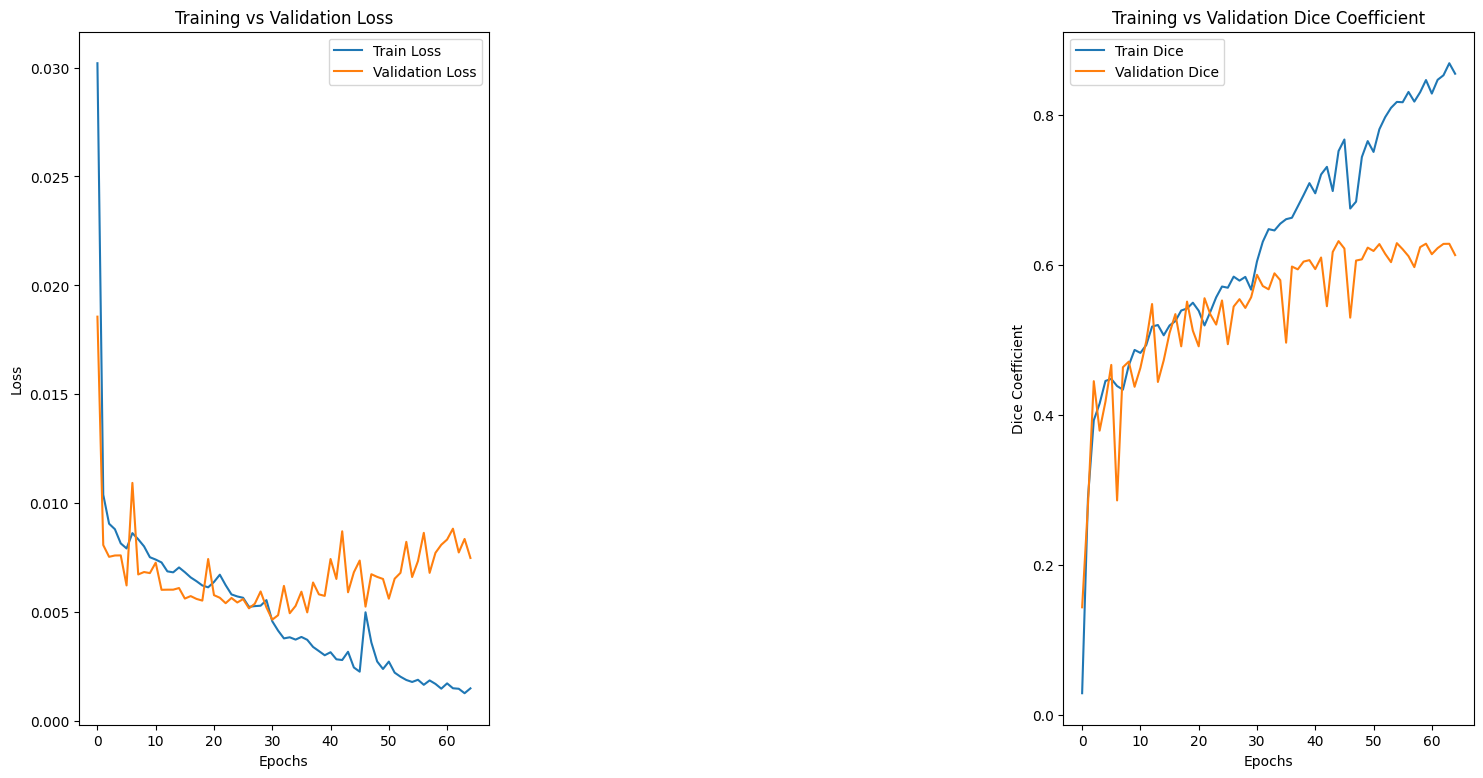

In [31]:
""" plotting the loss and accuracy during training and validation """
plt.figure(figsize=(18, 9))
plt.subplot(1, 3, 1)
plt.plot(unet_history.history['loss'])
plt.plot(unet_history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
# plt.subplot(1, 3, 2)
# plt.plot(unet_history.history['accuracy'])
# plt.plot(unet_history.history['val_accuracy'])
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.title('Training vs Validation Accuracy')
# plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.subplot(1, 3, 3)
plt.plot(unet_history.history['dice_coefficient'])
plt.plot(unet_history.history['val_dice_coefficient'])
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.title('Training vs Validation Dice Coefficient')
plt.legend(['Train Dice', 'Validation Dice'])

## Apaga alguns dados da memória

In [32]:
del unet_history
del train_data
del unet
gc.collect()

2884

## Carrega Modelo

In [33]:
""" Carregando o modelo salvo """
modelo = keras.models.load_model('modelos//unet_model_EGL_GeralV4.keras', custom_objects={'dice_coefficient': dice_coefficient, 'dice_loss': dice_loss, 'weighted_binary_crossentropy': weighted_binary_crossentropy})

## Testando com outros dados

In [34]:
""" Testando outras imagens """
path_x_new = 'banco2/TreinoGeral/EGL/validacaoGeralV4/x_test/'
path_y_new = 'banco2/TreinoGeral/EGL/validacaoGeralV4/y_test/'

x_new, nomes_x_new = banco(path_x_new, resolution=(256,256), grayscale= True, nomes= True)
y_new, nomes_y_new = banco(path_y_new, resolution=(256,256), grayscale= True, nomes= True)

# dict_x_new, x_new_mod = modificacoes1(x_new,
#              nomes_x_new,
#              original = True,
#              brilho = 1.7,
#              escura= 0.5)

# y_new_m, y_new_nomes = modificacoes2(dict(zip(nomes_y_new, y_new)), dict_x_new.keys())


# x_new_m = np.array(x_new_mod)
# y_new_m = np.array(y_new_m)


# print(f'Novas imagens : {x_new_m.shape}')
# print(f'Novos rótulos : {y_new_m.shape}')

class_test = np.array([0 if nome[2:3] == '6'  else 1 for nome in nomes_y_new], dtype=np.float32)

new_data = tf.data.Dataset.from_tensor_slices(((x_new, class_test), y_new))
new_data = new_data.batch(batch_size).prefetch(AUTOTUNE)
modelo.evaluate(new_data, verbose= 1)

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - dice_coefficient: 0.6779 - loss: 0.0071


[0.007065091747790575, 0.677916944026947]

diam_true=0.291 cm | diam_pred=0.208 cm | diam_diff=+0.083 cm | classe=Caracu


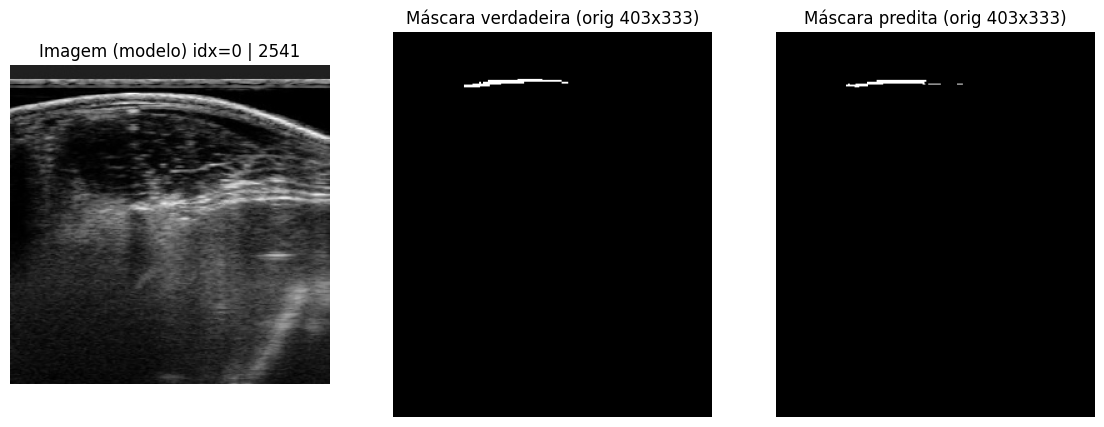

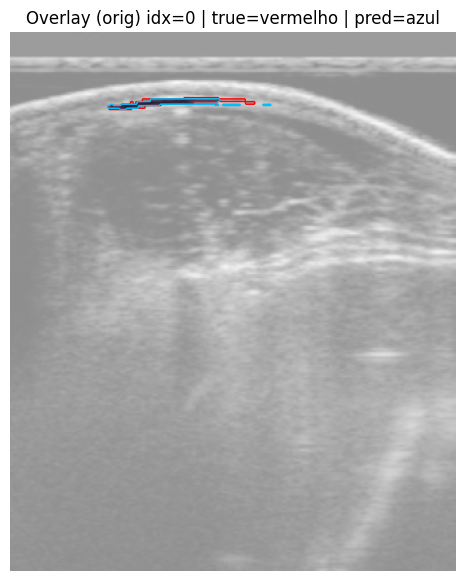

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Caracu


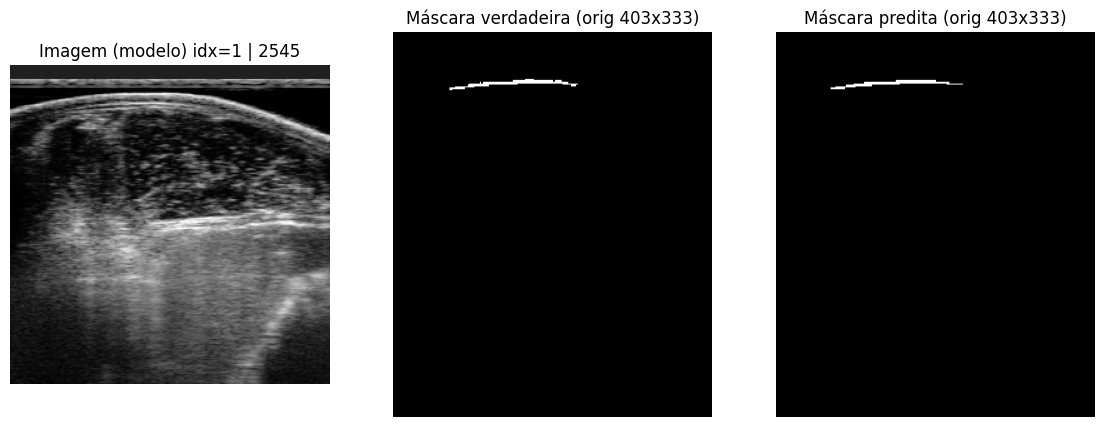

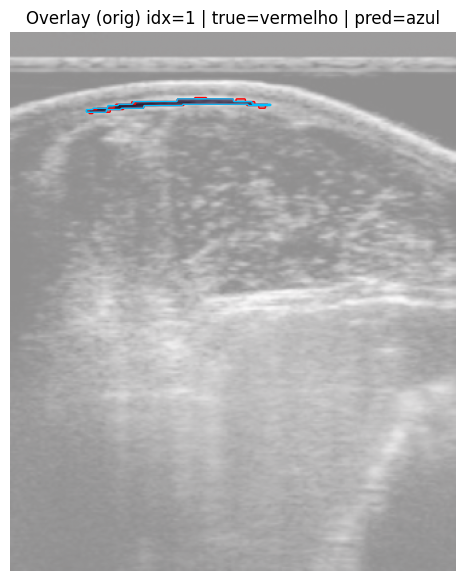

diam_true=0.291 cm | diam_pred=0.208 cm | diam_diff=+0.083 cm | classe=Caracu


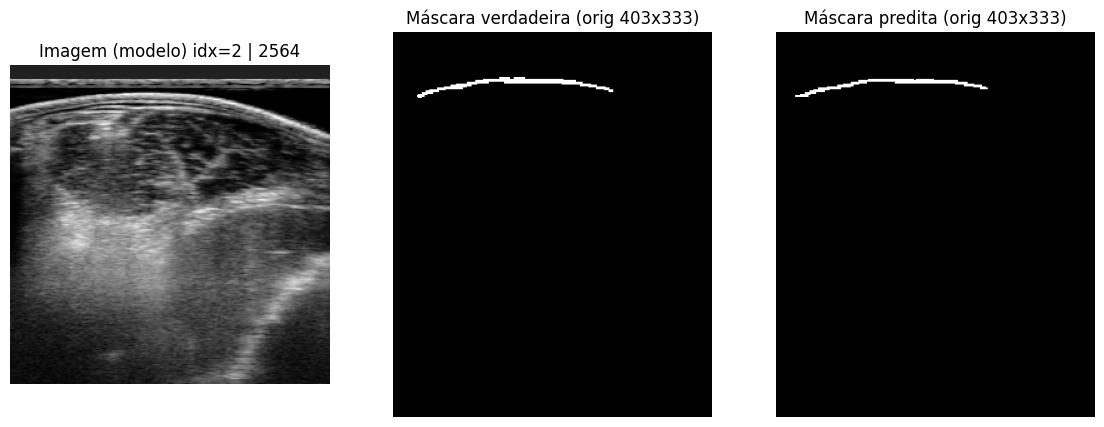

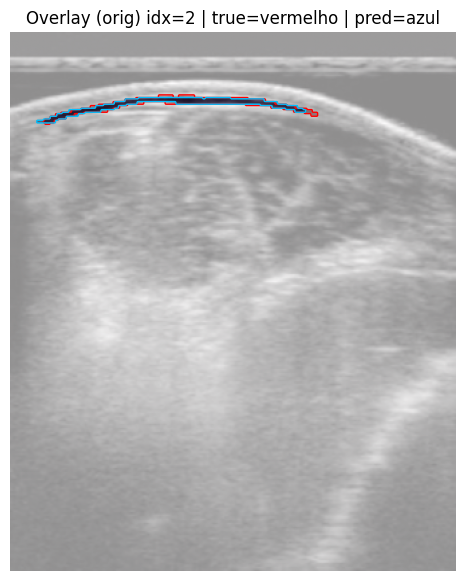

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Nelore


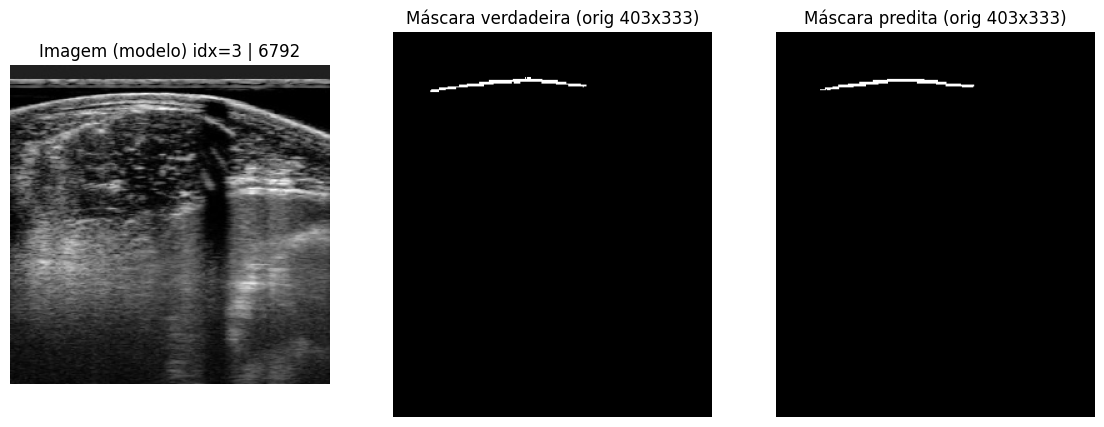

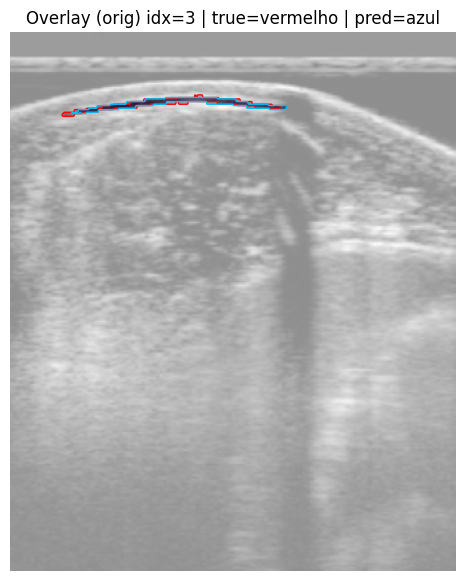

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Nelore


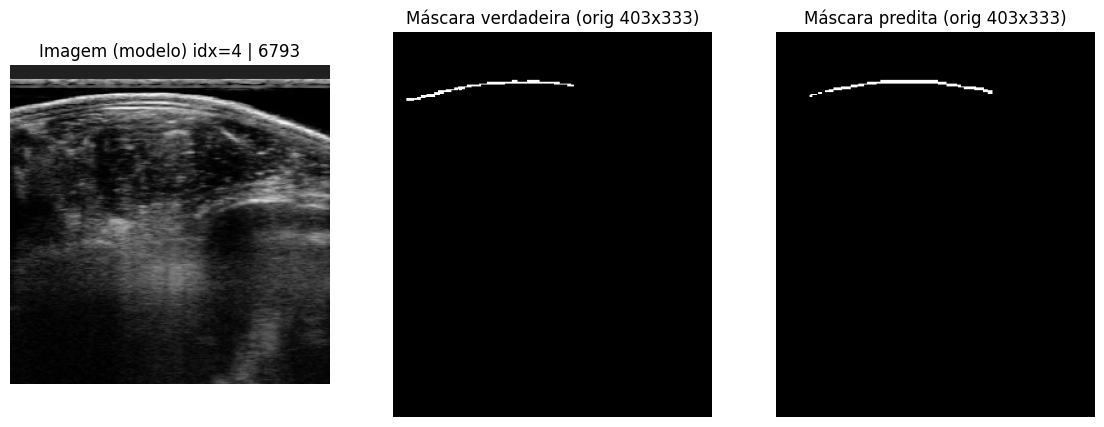

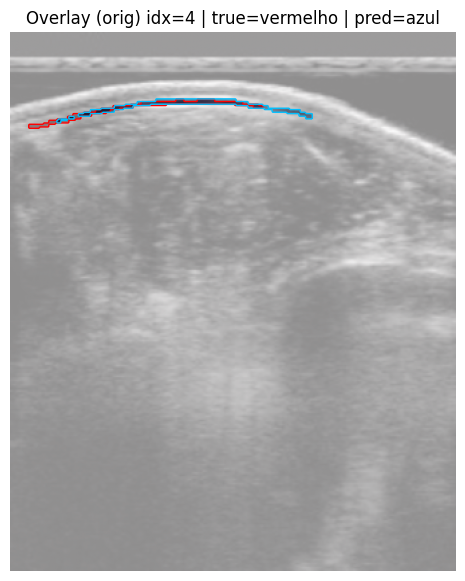

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Nelore


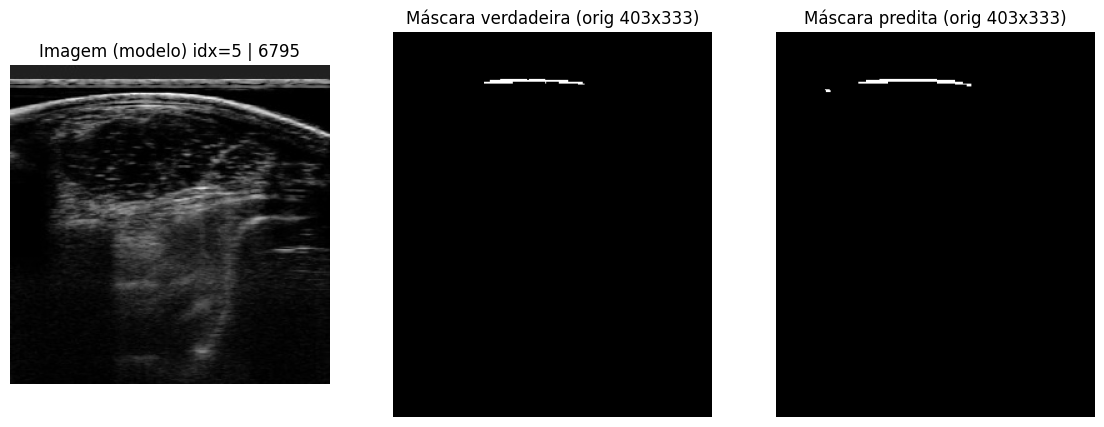

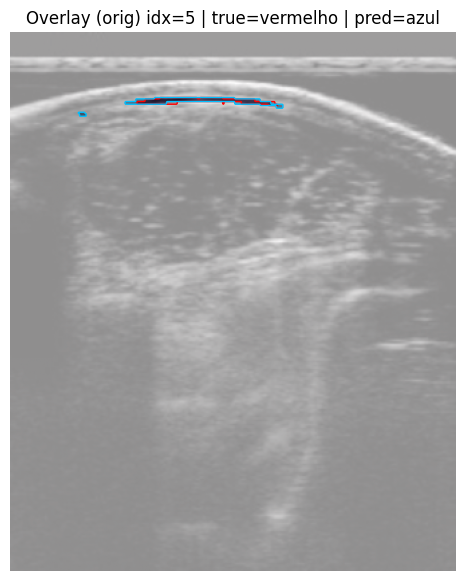

diam_true=0.166 cm | diam_pred=0.166 cm | diam_diff=+0.000 cm | classe=Nelore


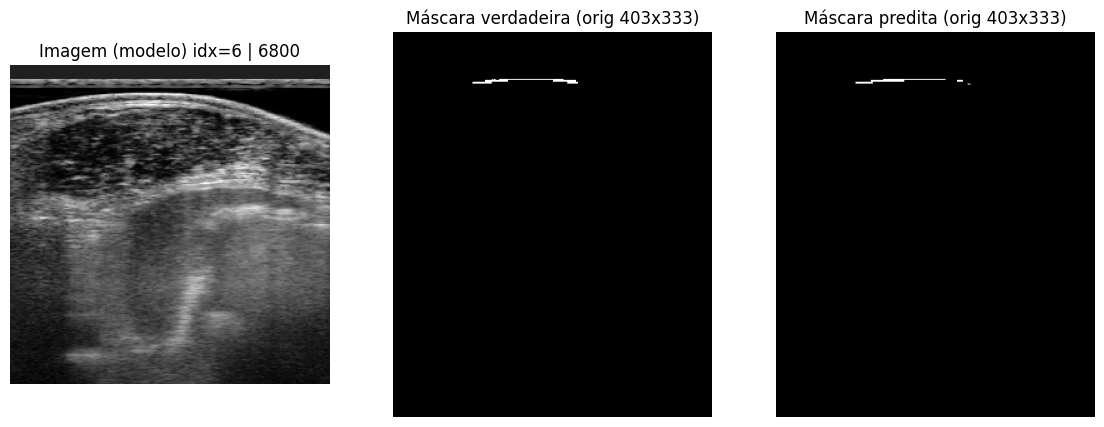

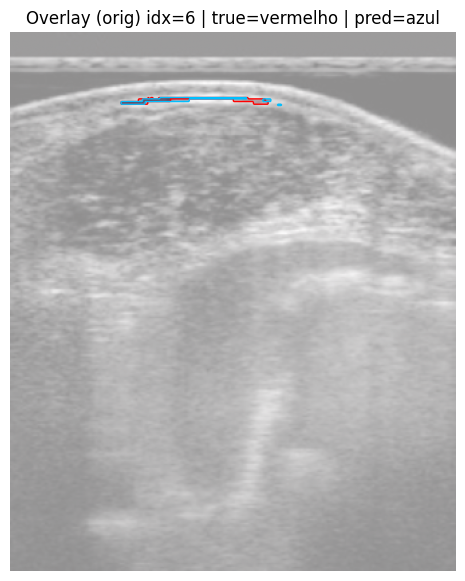

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Nelore


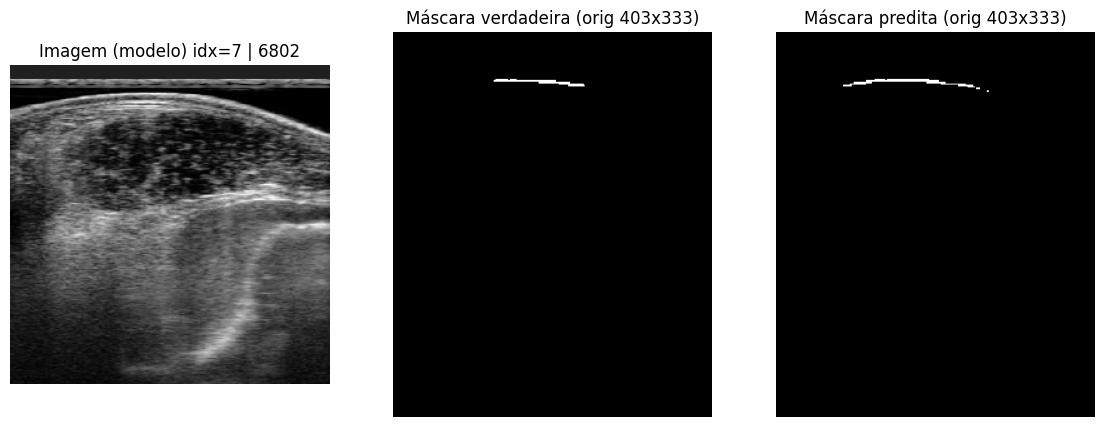

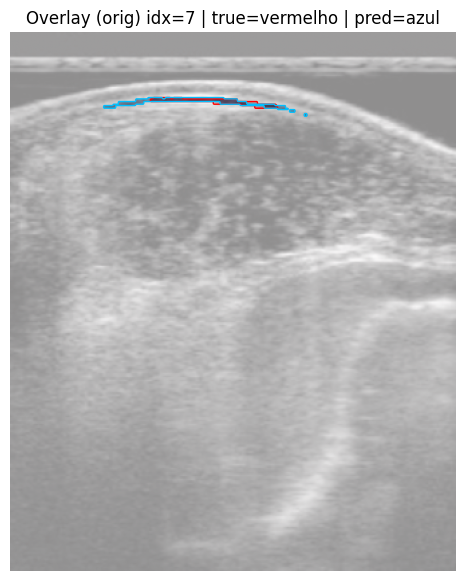

diam_true=0.166 cm | diam_pred=0.208 cm | diam_diff=+0.042 cm | classe=Nelore


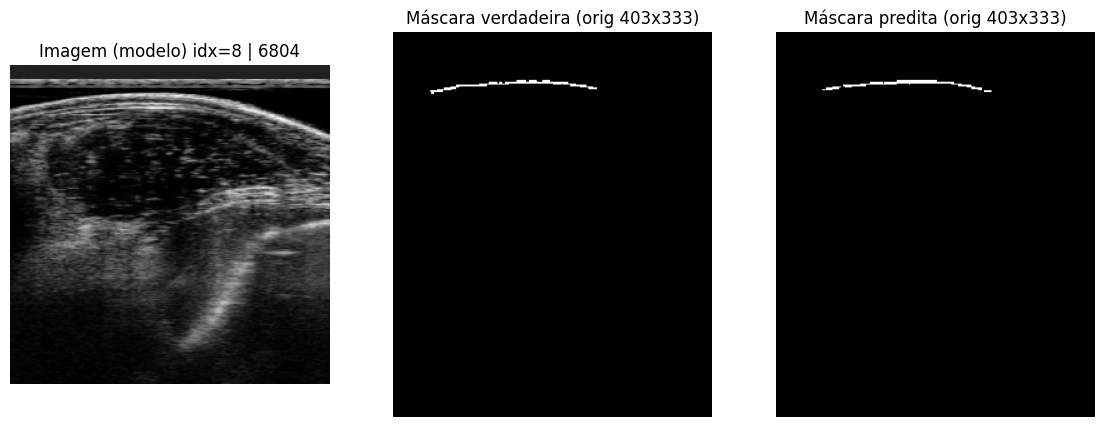

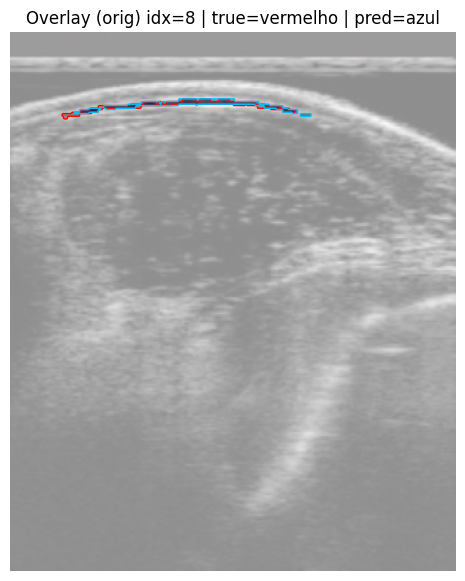

diam_true=0.166 cm | diam_pred=0.125 cm | diam_diff=+0.042 cm | classe=Nelore


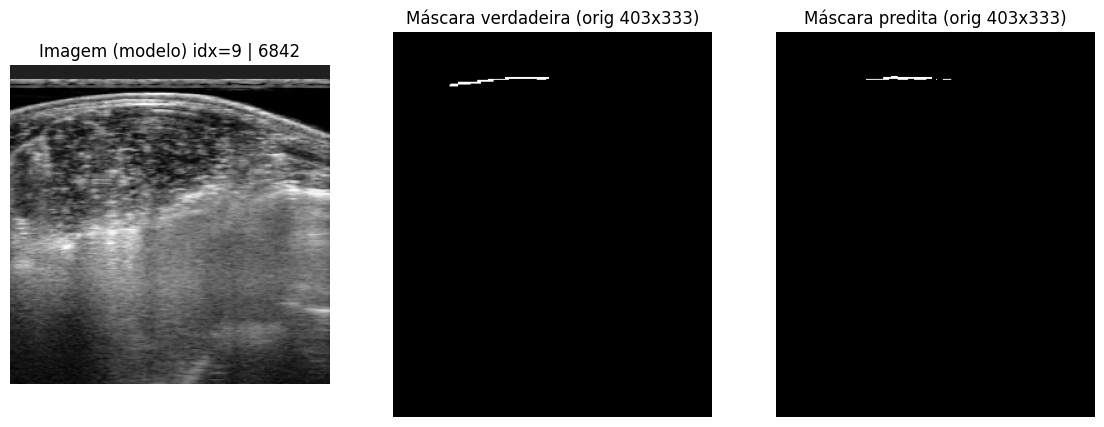

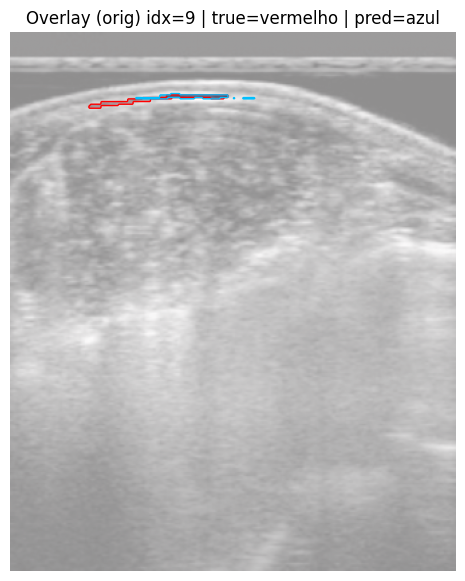

diam_true=0.166 cm | diam_pred=0.166 cm | diam_diff=+0.000 cm | classe=Nelore


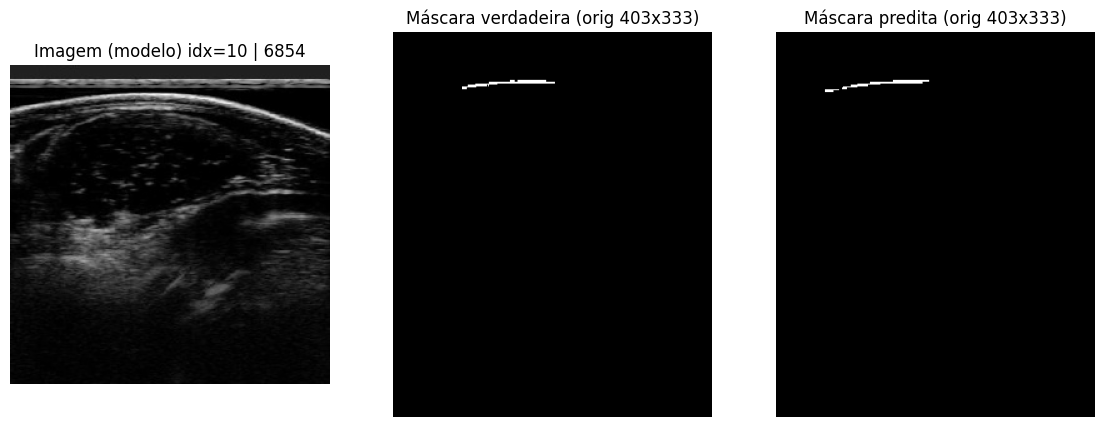

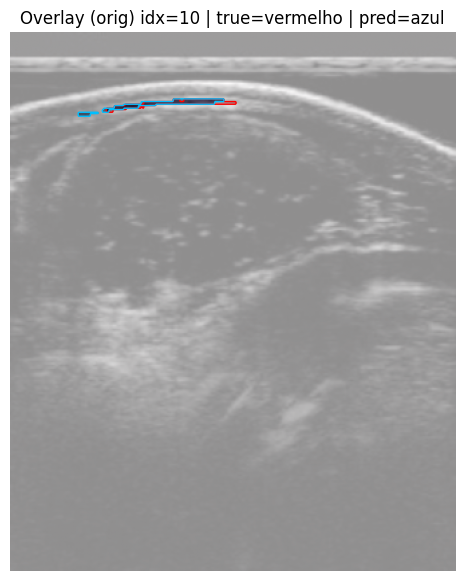

diam_true=0.249 cm | diam_pred=0.208 cm | diam_diff=+0.042 cm | classe=Nelore


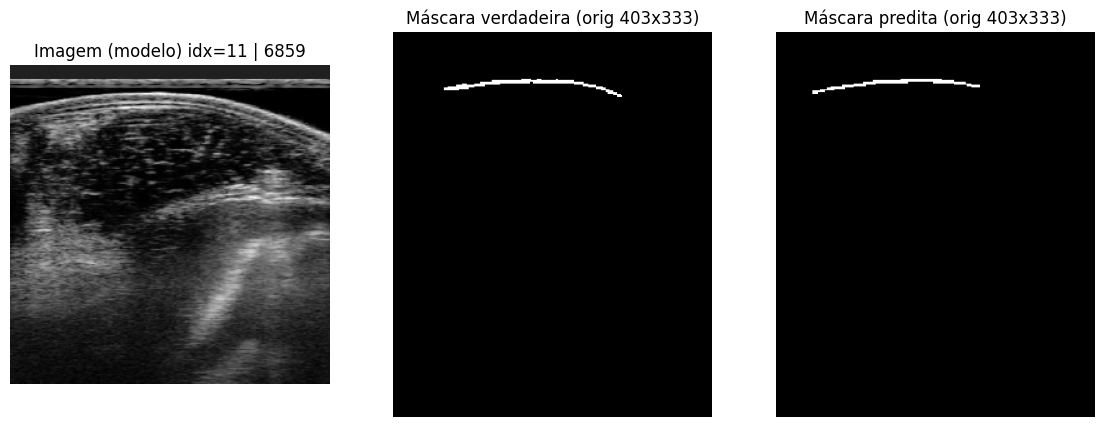

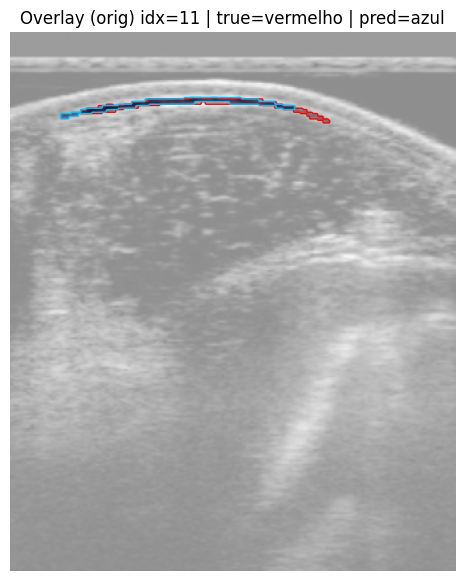

diam_true=0.208 cm | diam_pred=0.166 cm | diam_diff=+0.042 cm | classe=Nelore


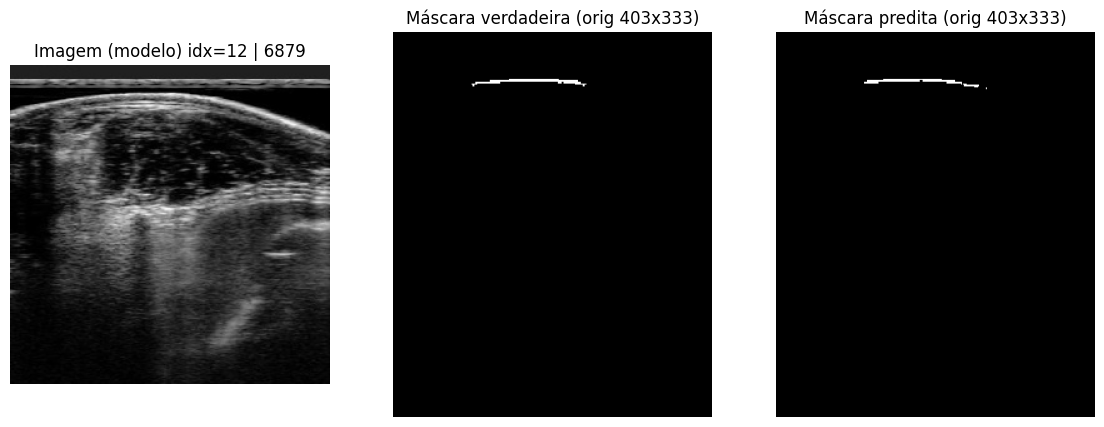

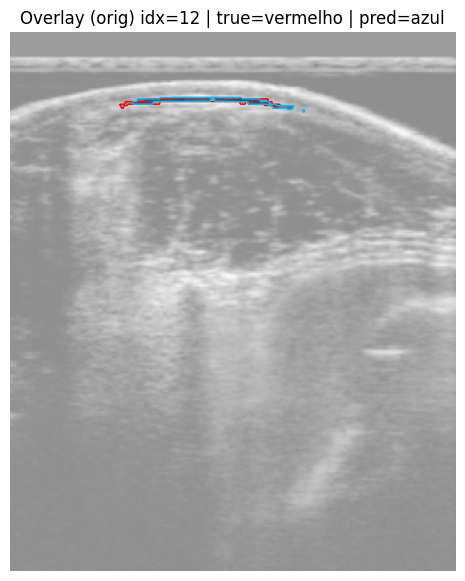

diam_true=0.208 cm | diam_pred=0.166 cm | diam_diff=+0.042 cm | classe=Nelore


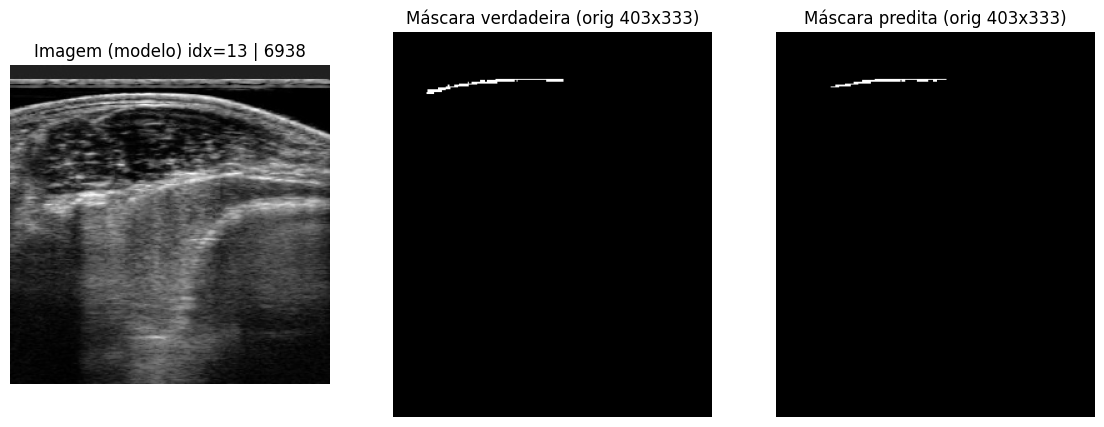

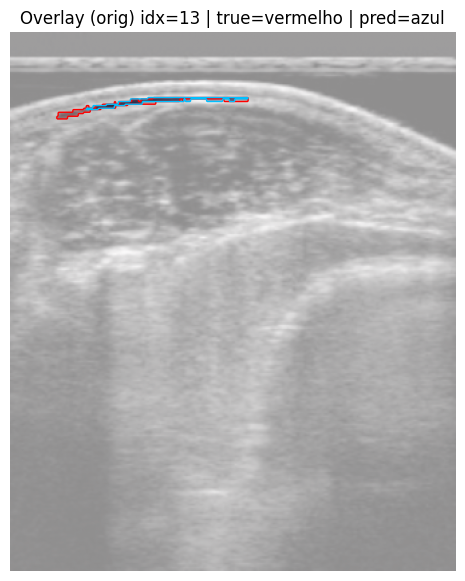

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Nelore


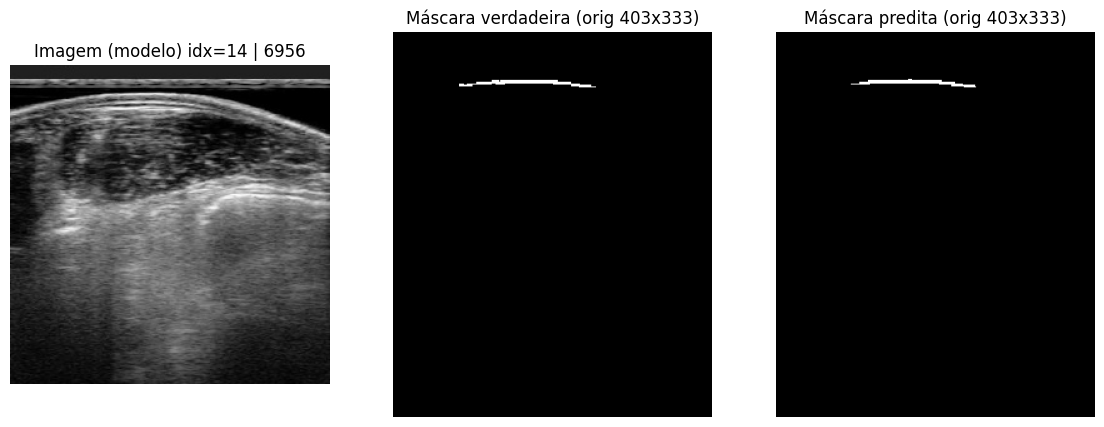

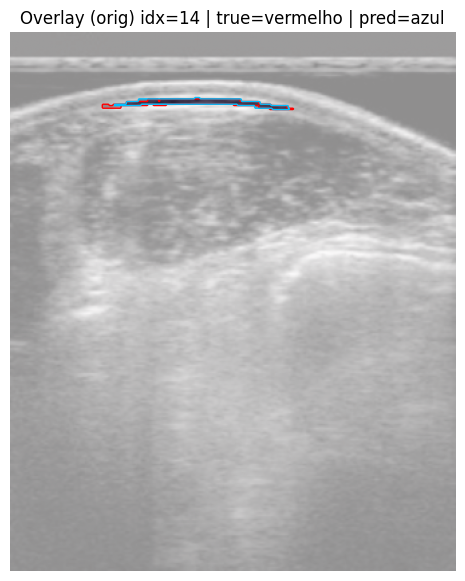

In [40]:
# Print função
for idx in range(len(x_new)):
    comparar_area_predicao(
        idx,
        modelo,
        (x_new, class_test),
        y_new,
        nomes_dados= nomes_y_new,
        orig_size=(403, 333),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=True,
        overlay_alpha=0.35,
        contours=True,
        verbose=True,
    )

In [41]:
""" Calculando a média dos erros"""
erros = []
area_real: list[float] = [] 
area_predita: list[float] = []
for idx in range(len(x_new)):
    resultado = comparar_area_predicao(
        idx,
        modelo,
        (x_new, class_test),
        y_new,
        nomes_dados= None,
        orig_size=(105, 213),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=False,
        overlay_alpha=0.35,
        contours=True,
        verbose=False,
    )
    erros.append(resultado['diam_diff_cm'])
    area_real.append(resultado['diam_true_cm'])
    area_predita.append(resultado['diam_pred_cm'])

In [ ]:
# Print dos erros
print(f'Erro médio na teste: {np.mean(np.abs(erros)):.3f} cm')
print(f'Erro Máximo na teste: {np.max(np.abs(erros)):.3f} cm')
print(f'Erro mínimo na teste: {np.min(np.abs(erros)):.3f} cm')

Erro médio na validação: 0.008 cm
Erro Máximo na validação: 0.042 cm
Erro mínimo na validação: 0.000 cm
